<a href="https://www.kaggle.com/code/nalisha/gaming-behavior-and-academic-performance-analysis?scriptVersionId=314882151" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<h2>
  <span style="color: blue; font-size: 18px;">Author:</span>
  <span style="font-size: 15px; font-weight: bold;">Aleesha Nadeem | 2(AN)K</span>
</h2>

## Overview
This project explores the relationship between students' gaming habits and their academic performance. 
The goal is to analyze patterns, **engineer meaningful features**, and **build predictive models** 
to understand how gaming impacts academic scores.

## Objectives
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Apply feature engineering
- Train and evaluate multiple regression models
- Compare model performance

##  Machine Learning Models Used
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor


# Import Libraries...

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from warnings import filterwarnings
filterwarnings("ignore")
import os

# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/gaming-vs-academic-performance/Gaming_Academic_Performance.csv")
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


# Data Cleaning

In [3]:
df.drop("student_id", axis=1, inplace=True)

In [4]:
df.shape

(8000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               8000 non-null   int64  
 1   gender            8000 non-null   object 
 2   gaming_hours      8000 non-null   float64
 3   study_hours       8000 non-null   float64
 4   sleep_hours       8000 non-null   float64
 5   attendance        8000 non-null   float64
 6   gaming_genre      8000 non-null   object 
 7   social_activity   8000 non-null   float64
 8   device_usage      8000 non-null   float64
 9   reaction_time_ms  8000 non-null   float64
 10  addiction_score   8000 non-null   float64
 11  stress_level      8000 non-null   object 
 12  grades            8000 non-null   float64
dtypes: float64(9), int64(1), object(3)
memory usage: 812.6+ KB


In [6]:
df.describe()

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [7]:
data = pd.DataFrame(df.columns, columns = ["Columns Name"])
data

,Columns Name
0,age
1,gender
2,gaming_hours
3,study_hours
4,sleep_hours
5,attendance
6,gaming_genre
7,social_activity
8,device_usage
9,reaction_time_ms


In [8]:
df.isnull().sum()

age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

**Convert Categorical to Numerical**

Categorical columns:

- gender
- gaming_genre
- device_usage

Use **One-Hot Encoding:**

In [10]:
df = pd.get_dummies(df, drop_first=True)

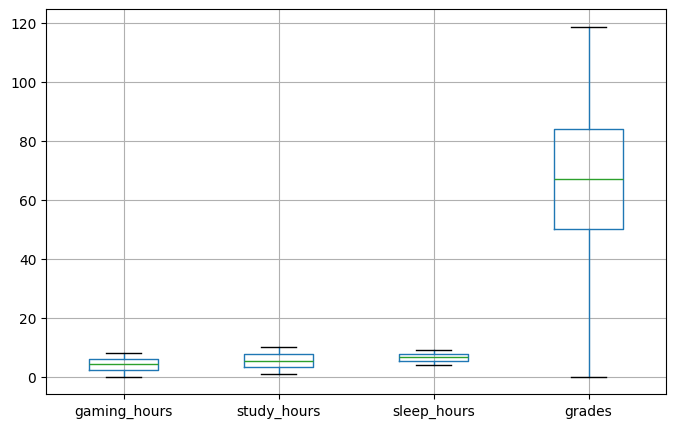

In [11]:
df[['gaming_hours','study_hours','sleep_hours','grades']].boxplot(figsize=(8,5))
plt.show()

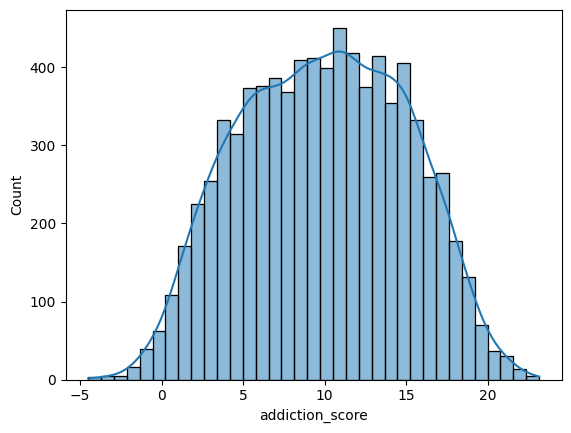

In [12]:
sns.histplot(df['addiction_score'], kde=True)
plt.show()


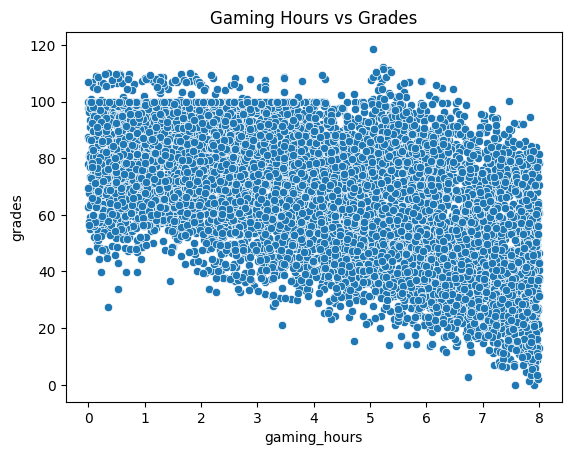

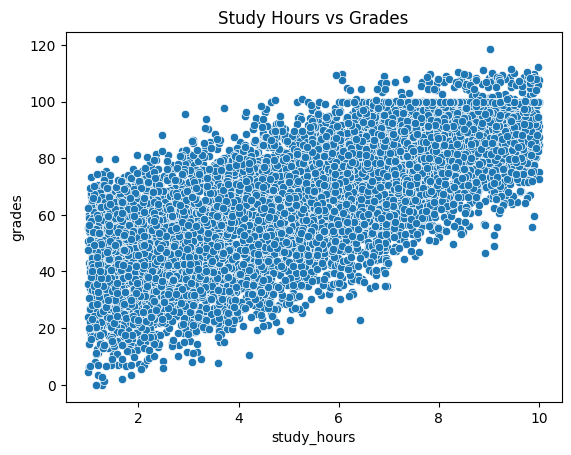

In [13]:
sns.scatterplot(x=df['gaming_hours'], y=df['grades'])
plt.title("Gaming Hours vs Grades")
plt.show()

sns.scatterplot(x=df['study_hours'], y=df['grades'])
plt.title("Study Hours vs Grades")
plt.show()

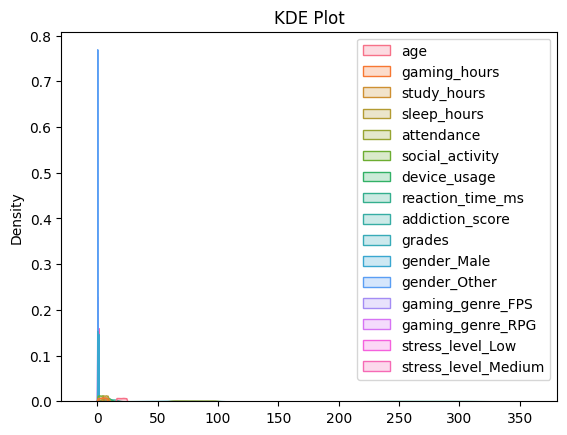

In [14]:
sns.kdeplot(df, fill=True)

plt.title("KDE Plot")
plt.show()

# Features and Target

In [15]:
X = df.drop("grades", axis=1)
y = df["grades"]

# Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (Only for Linear Regression)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training 😎

### 🔹 Linear Regression

In [18]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
pred_lr

array([45.49346628, 73.86034   , 49.2177724 , ..., 53.84888013,
       97.40583952, 85.50785528])

### 🔹 Random Forest

In [19]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
pred_rf

array([44.83819569, 71.72356871, 51.03639638, ..., 56.87384486,
       95.27267541, 88.48975623])

### 🔹 XGBoost

In [20]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

## Model Evaluation Function

In [21]:
def evaluate(y_true, y_pred):
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

In [22]:
print("Linear Regression")
evaluate(y_test, pred_lr)

print("\nRandom Forest")
evaluate(y_test, pred_rf)

print("\nXGBoost")
evaluate(y_test, pred_xgb)

Linear Regression
R2 Score: 0.9032054475645133
MAE: 5.5038795125934925
RMSE: 6.965509672630382

Random Forest
R2 Score: 0.9210746032501206
MAE: 4.8685586703288335
RMSE: 6.289785405675732

XGBoost
R2 Score: 0.916341702140958
MAE: 5.025207274538457
RMSE: 6.4756289152967526


# Feature Importance

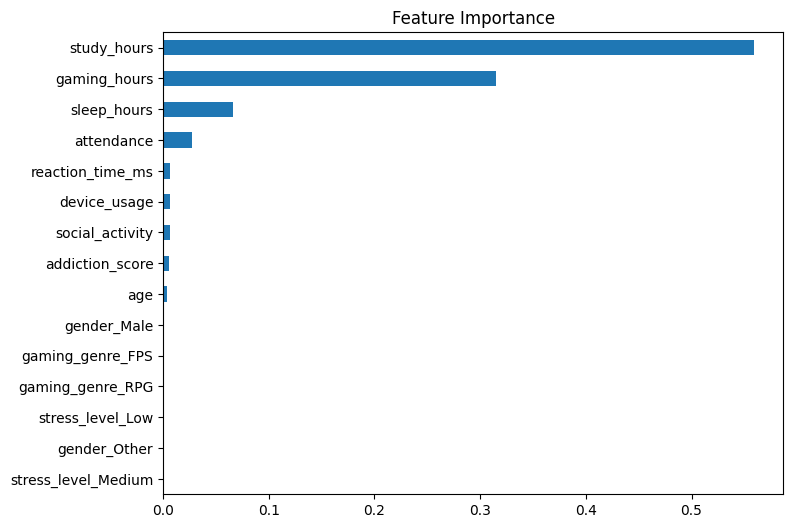

In [23]:
importance = rf.feature_importances_
feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

# Check Overfitting

In [24]:
rf.score(X_train, y_train)
rf.score(X_test, y_test)

0.9210746032501206

# Add Cross Validation

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("CV Score:", scores.mean())

CV Score: 0.9278201207821255


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

  <h2 style="color: #2c3e50;">🎯 Conclusion</h2>
  
  <p>
    This analysis shows that academic performance is strongly influenced by 
    <strong>study hours</strong>, <strong>attendance</strong>, and 
    <strong>lifestyle balance</strong>. Gaming itself is not harmful — 
    but <strong>excessive gaming</strong> can negatively impact grades.
  </p>

  <p>
    Among the models, <strong>Random Forest</strong> and 
    <strong>XGBoost</strong> performed better than 
    <strong>Linear Regression</strong>, indicating that student performance 
    patterns are not purely linear.
  </p>

  <h3 style="color: #34495e;">📚 In short:</h3>


  <p style="font-style: italic; font-weight: bold;">
    Success is less about quitting games and more about managing time wisely.
  </p>

</div>
<hr>

<div style="margin-top: 30px; text-align: center; font-family: Arial, sans-serif;">

  <p style="font-size: 16px;">
    Thank you for reviewing my notebook.
  </p>

  <p style="font-size: 16px; font-style: italic;">
    Stay curious, stay balanced, and keep experimenting.
  </p>

  <p style="margin-top: 10px; font-weight: bold;">
    — 2(AN)K — 
  </p>

</div>



<hr>